この練習問題では、タイタニック号の乗客の情報を利用して、各乗客が生き残るか否かを予測するモデルの作成に挑戦します。   

##### 目次
1. データを読み込もう
1. データの概要を確認しよう
1. データを分析してみよう
1. データの前処理をしよう
1. モデリングをしてみよう
1. 予測結果を投稿しよう

## 1. データを読み込もう

pandasをインポートして、ダウンロードした学習用データ、評価用データ、応募用サンプルファイルを読み込みます。

In [ ]:
import pandas as pd
train = pd.read_csv("train.csv", index_col=0) # 学習用データ
test = pd.read_csv("test.csv", index_col=0)   # 評価用データ
sample_submit = pd.read_csv("sample_submit.csv", index_col=0, header=None) # 応募用サンプルファイル

## 2. データの概要を確認しよう

読み込んだ学習用データの先頭5行を表示してみましょう。

In [2]:
train.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
id,,,,,,,,
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
7,0,3,male,2.0,3,1,21.0750,S
9,1,2,female,14.0,1,0,30.0708,C
11,1,1,female,58.0,0,0,26.5500,S


1行で乗客1人の情報を表していて、カラムは8種類あることが分かります。各カラムの意味は、データタブに記載されているのでそれと照らし合わせて確認できます。黄色く色付けされた`survived（生還結果）`が今回の予測の対象である目的変数で、1が生還、0が亡くなってしまったということを表してることが分かります。
 
 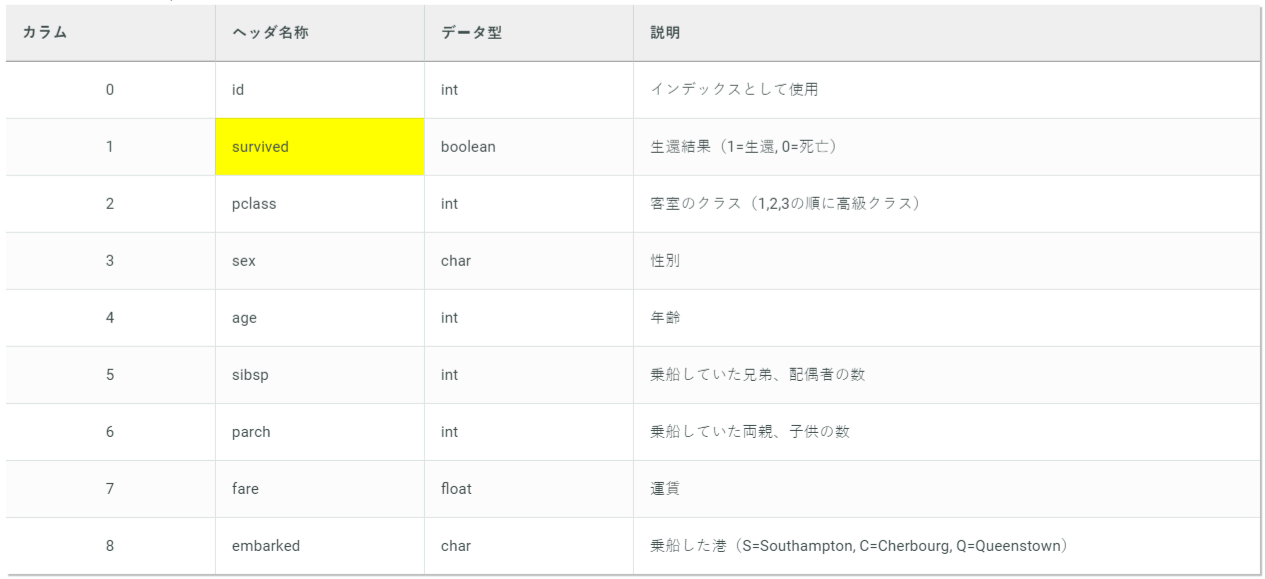

続いて評価用データの先頭5行も表示してみましょう。

In [3]:
test.head()

,pclass,sex,age,sibsp,parch,fare,embarked
id,,,,,,,
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
5,3,male,NaN,0,0,8.4583,Q
6,1,male,54.0,0,0,51.8625,S


学習用データにはあった目的変数であるカラム`survived`が無いことが分かります。その他のカラムは学習用データと同じです。つまり、答えのある学習用データの乗客の情報を元にして機械学習により生存の法則をモデル化し、そのモデルを評価用データに当てはめて、評価用データに記録されている各乗客が生存できるのか否かを予測することが課題になります。

データのサイズも見てみます。

In [4]:
print(train.shape)
print(test.shape)

(445, 8)
(446, 7)


学習用データは445人の乗客情報で、評価用データは446人です。この446人の生存結果を予測します。評価用データには`survived`がないので、カラム数は学習用データより一つ少なくなっていることがここでも確認できますね。

カラムの情報も見てみましょう。

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 445 entries, 3 to 888
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  445 non-null    int64  
 1   pclass    445 non-null    int64  
 2   sex       445 non-null    object 
 3   age       360 non-null    float64
 4   sibsp     445 non-null    int64  
 5   parch     445 non-null    int64  
 6   fare      445 non-null    float64
 7   embarked  443 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 31.3+ KB


`age`を見るとデータ数が360となっており、他のデータよりも少なくなっています。これから、何人かの乗客は年齢や乗船した港の情報が存在しない、つまり値が欠損しているということが分かりました。`embarked`も2つ欠損があるようです。評価用データも同様に確認すると、学習用データと同様、`age`に欠損値があることが分かります。また、`sex`と`embarked`は、データタイプが`object`、つまりカテゴリ変数であることも分かります。

## 3. データを分析してみよう

そもそも、この遭難事故ではどれくらいの人々が生還したのでしょうか？またそれはどのような属性の人でしょうか？これらの疑問について仮説を立てながら、学習用データを分析していきましょう。生き残りに有用な特徴を見つけることができれば、データのクレンジングや新しい変数の追加などによって、モデルの予測精度向上が見込めます。

まず、目的変数である`survived`の値の出現数をカウントすることで、生存できた人の数を調べてみます。

In [6]:
train['survived'].value_counts()

0    266
1    179
Name: survived, dtype: int64

生存できた人の割合は約40%と、映画「タイタニック」で受けた印象よりは多いようです。

次に、数値データの統計値を見てみましょう。

In [7]:
train.describe()

,survived,pclass,age,sibsp,parch,fare
count,445.000000,445.000000,360.000000,445.000000,445.000000,445.000000
mean,0.402247,2.296629,29.211583,0.546067,0.431461,33.959971
std,0.490903,0.834024,14.154300,1.195247,0.850489,52.079492
min,0.000000,1.000000,0.670000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.000000
75%,1.000000,3.000000,37.250000,1.000000,1.000000,31.387500
max,1.000000,3.000000,80.000000,8.000000,5.000000,512.329200


結果から、例えば次のことが分かります。

 - `pclass`の中央値は3であり、乗客の過半数は一番下の3等室に乗っていたようです。
 - `age`を見ると、平均年齢は29歳と若めです。
 - `fare`の平均値は約33ですが、最大値は約512であり、非常に高額の運賃を払っていた人もいるようです。

先程、性別と乗船した港はカテゴリ変数であることを確認しました。

ここでは、学習用データのカテゴリ変数をダミー化してみます。ダミー化とは、例えば性別カテゴリを`男性→0`, `女性→1`といったように、カテゴリを数値に変換することです。`pandas`の`get_dummies`関数を用いるとカテゴリが数値に変換され、こうすることで特徴量同士の相関係数を算出したり、機械に学習させることが可能になります。

学習用データのカテゴリ変数をダミー化した上で、目的変数`survived`と各カラムとの相関係数を見てみましょう。  

In [8]:
pd.get_dummies(train).corrwith(train["survived"])

survived      1.000000
pclass       -0.358097
age          -0.081394
sibsp        -0.045087
parch         0.079669
fare          0.258605
sex_female    0.559465
sex_male     -0.559465
embarked_C    0.182568
embarked_Q    0.005062
embarked_S   -0.172769
dtype: float64

相関係数が 1 に近いと正の相関、-1 に近いと負の相関が強く、0に近いと相関が弱いことを表します。結果から、性別や客室クラスとの相関が強く、年齢や乗船した港やとの相関は比較的弱いようです。高級なクラスに乗っていた人や女性が優先的に救命ボートに乗せられたのでしょうか。

実際に客室クラスごとの生存率を見ていきましょう。

In [9]:
train[['pclass', 'survived']].groupby(['pclass']).mean()

,survived
pclass,
1,0.685185
2,0.443299
3,0.258333


`pclass`が1に近い高級クラスほど、`survived`が1の割合が多い、つまり生存率が高くなっています。

性別と生存率の関係も調べましょう。

In [10]:
train[['sex', 'survived']].groupby(['sex']).mean()

,survived
sex,
female,0.775641
male,0.200692


女性の生存率が圧倒的に高いです。以上から、女性や客室クラスが高い乗客は優先的に救助ボートに乗せられた可能性が考えられます。映画でもそういったシーンがありましたね。

本チュートリアルでは簡単な分析のみを行いましたが、他のカラムも詳しく見ていけば、様々な発見があるのでトライしてみましょう。

## 4. データの前処理をしてみよう

データの確認の結果、欠損やカテゴリ変数が含まれていることが分かったので、欠損値の補完やカテゴリ変数のダミー化を行います。学習用データと評価用データを一括で処理するため、まずは両データを結合します。

In [11]:
data = pd.concat([train, test])

欠損値の扱いはデータ分析を行う上で非常に重要です。対応方法はいろいろありますが、今回は、`age`には全体の平均値、`embarked`には最頻値で補完してみます。

In [12]:
data['age'] = data['age'].fillna(data['age'].mean()) 
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()) 

続いて`data`をダミー化します。

In [13]:
data = pd.get_dummies(data)

前処理を施したデータを元の学習用データと評価用データに戻します。また、結合時に評価用データに`survived`が追加されてしまったのでそれは削除しておきましょう。

In [14]:
train = data.loc[train.index]
test = data.loc[test.index]
test = test.drop(["survived"], axis=1)

学習用データの先頭5行をもう一度見てみましょう。

In [15]:
train.head()

,survived,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
id,,,,,,,,,,,
3,1.0,1,35.0,1,0,53.1000,1,0,0,0,1
4,0.0,3,35.0,0,0,8.0500,0,1,0,0,1
7,0.0,3,2.0,3,1,21.0750,0,1,0,0,1
9,1.0,2,14.0,1,0,30.0708,1,0,1,0,0
11,1.0,1,58.0,0,0,26.5500,1,0,0,0,1


性別と乗船した港がダミー化されて、カラム数が増え、要素が全て数値データになっていることが確認できます。

## 5. モデリングをしてみよう

モデリングの準備として、目的変数とそれ以外に学習用データを分割しておきます。

In [16]:
y = train["survived"] # 目的変数
X = train.drop(["survived"], axis=1) # 目的変数を除いたデータ

基礎編と同様に、`scikit-learn`を使用して、`ロジスティック回帰`でモデルを学習してみます。パラメータをデフォルトのままにする場合、モデルの箱を作成してデータを当てはめるだけというシンプルな方法で学習できます。

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

これでモデルが作成できました！

学習したモデルに評価用データを入力すると、評価用データに対する生存した確率を出力してくれます。このとき戻り値には生存できる確率と生存できない確率の両方が含まれるため、生存できる確率の方を取り出します。

In [18]:
pred = model.predict_proba(test)[:, 1] 

予測結果には、評価用データの並び順に合わせて、生存できる確率が格納されます。先頭の5要素を表示してみます。

In [19]:
print(pred[:5])

[0.10431141 0.92126809 0.63747044 0.1737163  0.28561366]


##  6. 予測結果を投稿しよう

応募用サンプルファイルの説明を見ると、以下のように指定されています。

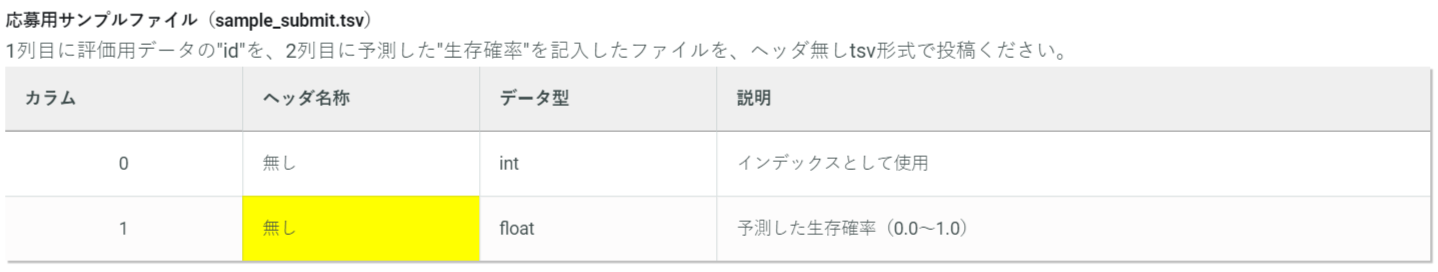

応募用サンプルファイルで予測結果が格納されている1列目の値を、今回出力した予測結果に置き換えた上で、ヘッダ無しcsv形式のファイルとして保存しましょう。

In [ ]:
sample_submit[1] = pred
sample_submit.to_csv('submit.csv', header=None)

これで投稿ファイルの完成です！保存したファイルをサイト右上の「投稿」ボタンから投稿してみましょう。

投稿してしばらくすると、今回の評価関数「AUC」での評価結果がメールで通知され、リーダーボードにも評価結果と順位が表示されます。

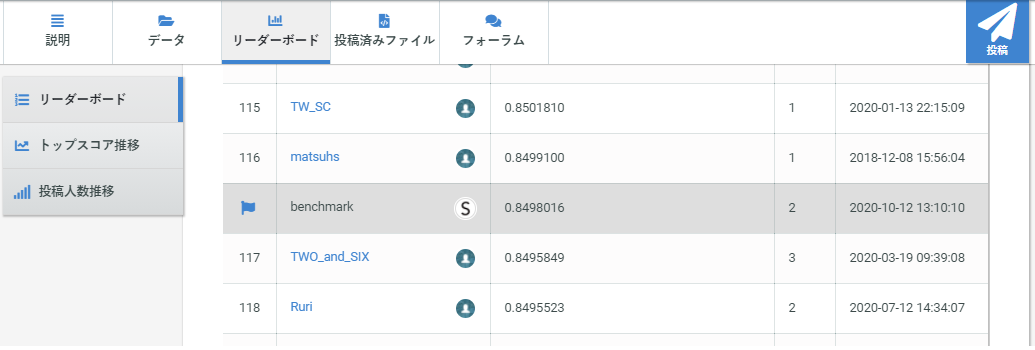

評価結果は`0.8498016`でした。  

基礎編での評価結果は `0.7087515` でしたが、使用する特徴量を増やすことで精度を大きく改善することができました。


SIGNATEでは、練習問題の他、トライアウトやSOTA、懸賞付きコンペなど、様々な形式のコンペを開催しています。モデル構築に慣れてきたら、これらのコンペにもチャレンジしてみましょう！